# Monte Carlo simulator for prop firm challenges

This notebook implements, step by step, the same Monte Carlo framework (block bootstrap) presented in the theory part of the video: given the historical returns of a strategy, we estimate the probability of passing a prop firm challenge, the expected value per attempt, the cost of getting a funded account, and the probability of bankroll ruin.

## 1. Historical data

Load historical candle log returns from a parquet file.

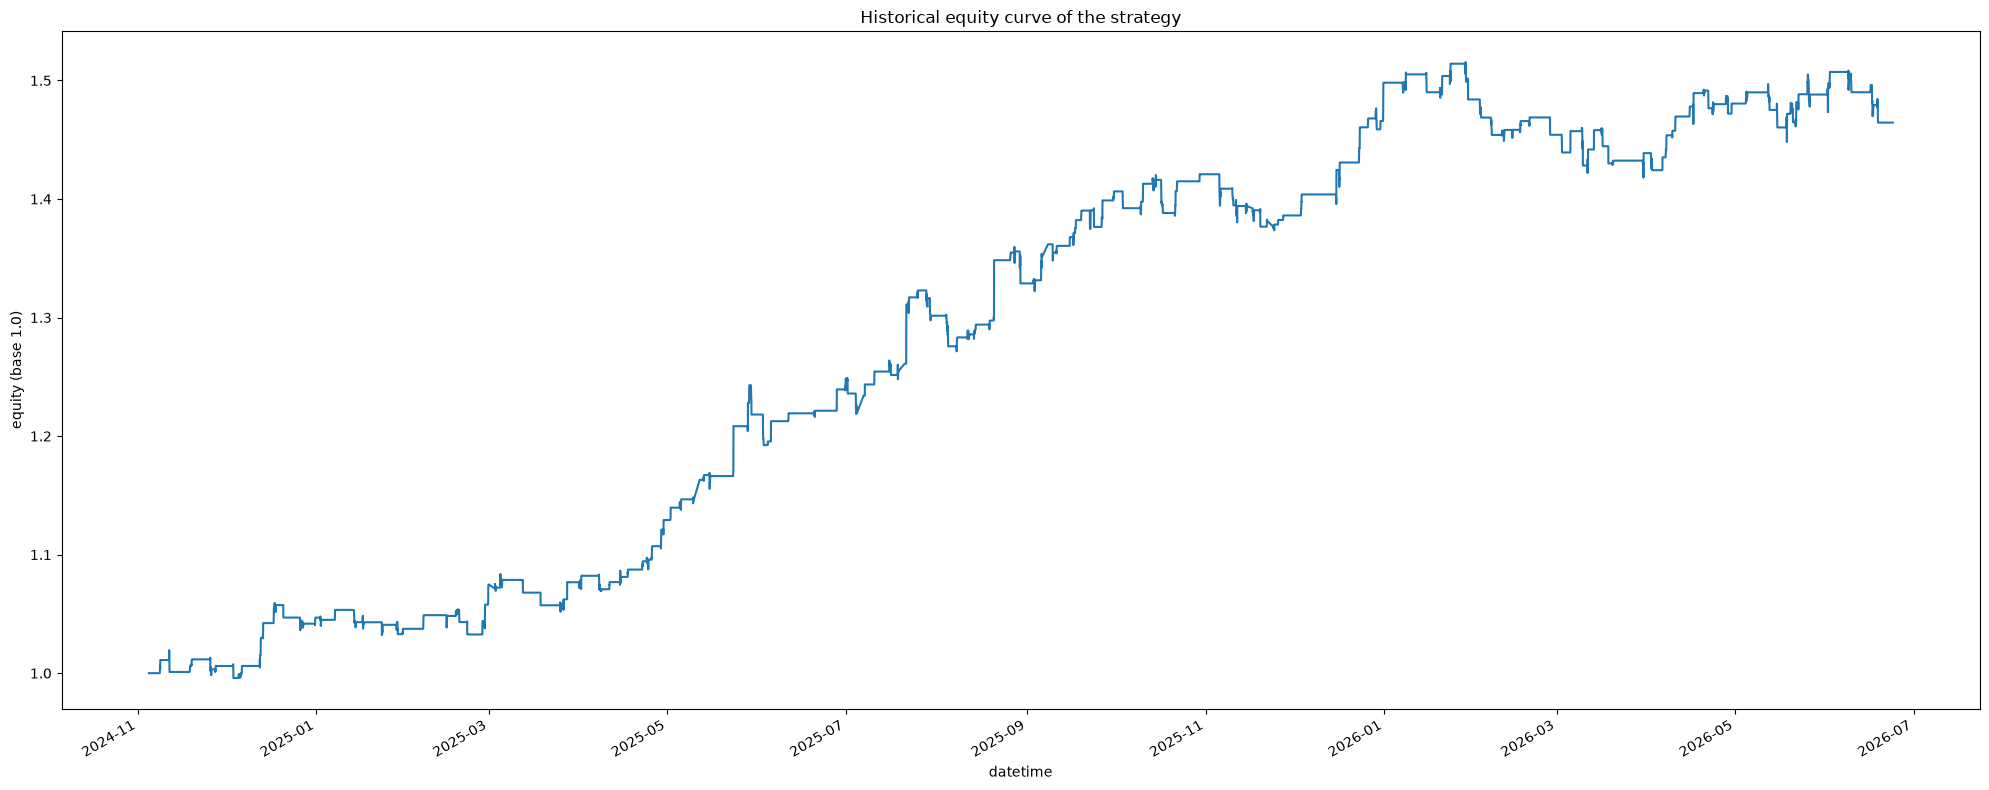

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

log_returns = pd.read_parquet("mean_reversion_strategy.parquet").squeeze()

fig, ax = plt.subplots(figsize=(20, 8))
(np.exp(log_returns.cumsum())).plot(ax=ax)
ax.set_title("Historical equity curve of the strategy")
ax.set_ylabel("equity (base 1.0)")
plt.tight_layout()
plt.show()

## 2. Challenge parameters

- `tp` / `sl`: profit target and cumulative stop loss, as a % of capital
- `daily_sl`: maximum allowed daily loss
- `bars_per_day` / `bars_per_month`: how many bars make up a day / a month at your data's frequency (here daily, so 1 and ~21 respectively)
- `n_bars`: maximum simulated horizon (max challenge duration)
- `challenge_cost`, `fixed_cost_month`, `payout_pct`, `bankroll`: cost and payout structure
- `block_size`: length of the blocks sampled in the bootstrap

> Note: we use daily data here for teaching simplicity. With intraday data, `bars_per_day` should be set accordingly to correctly capture intraday excursion in the daily loss limit test.

In [3]:
params = {
    "tp" : 0.15,
    "sl" : 0.10,
    "daily_sl" : 0.05,
    "trailing_sl" : False,
    "bars_per_day" : 23,
    "days_per_month" : 21,
    "n_days" : 252,
    "capital" : 100_000,
    "challenge_cost" : 650,
    "fixed_cost_month" : 15,
    "payout_pct" : 0.80,
    "bankroll" : 10000,
    "block_size" : 1,
}

params["bars_per_month"] = params["days_per_month"] * params["bars_per_day"]
params["n_bars"] = params["n_days"] * params["bars_per_day"]

leverage_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

## 3. Block bootstrap: why resample in blocks

Instead of assuming a theoretical distribution (e.g. Gaussian), we resample **contiguous blocks** of the strategy's real history. This preserves the autocorrelation and market regimes (good/bad days that cluster together) that independent sampling would destroy. Each generated path is a plausible alternative history, built by reshuffling real pieces of the strategy — not a statistical invention.

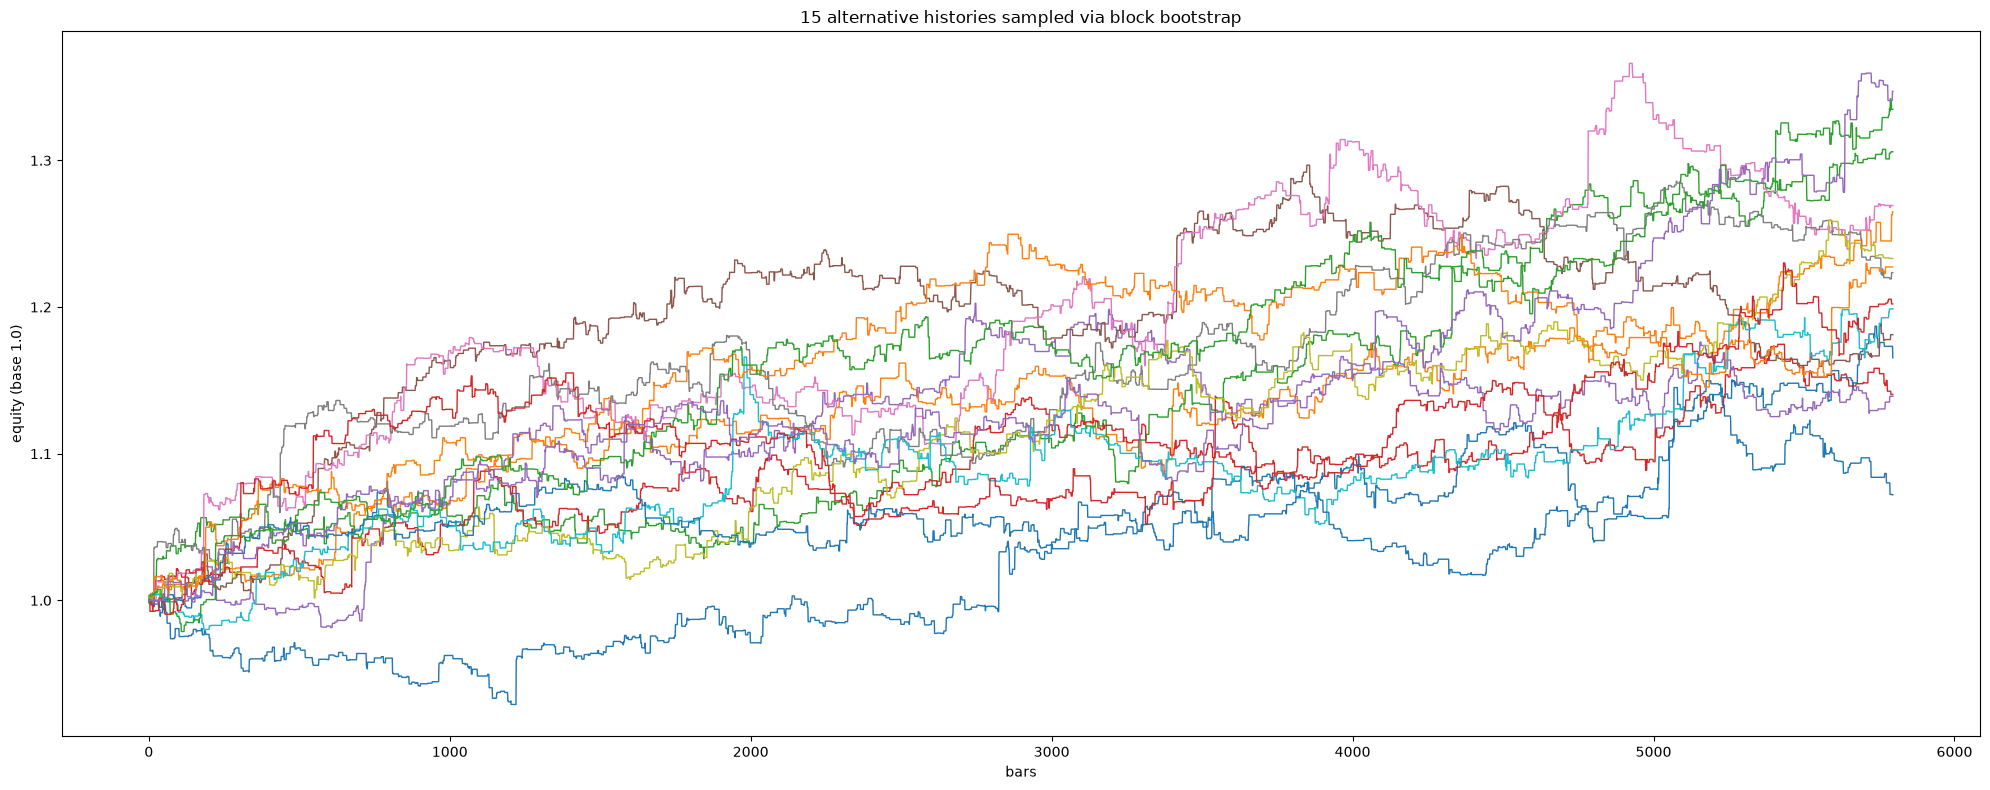

In [14]:
def sample_bootstrap_path(returns_simple, p, rng):
    T = len(returns_simple)
    block_size = min(T, max(1, p["block_size"]))
    n_blocks = int(np.ceil(p["n_bars"] / block_size))
    max_start_idx = T - block_size

    start_idx = rng.integers(0, max_start_idx + 1, size=n_blocks)
    r = np.concatenate(
        [returns_simple[s : s + block_size] for s in start_idx]
    )[: p["n_bars"]]
    return r


returns_simple = (np.exp(log_returns.dropna()) - 1).values  # log -> simple return

rng_demo = np.random.default_rng()
fig, ax = plt.subplots(figsize=(20, 8))
for _ in range(15):
    r = sample_bootstrap_path(returns_simple, params, rng_demo)
    cum = (1 + r).cumprod()
    ax.plot(cum, alpha=1, linewidth=1)
ax.set_title("15 alternative histories sampled via block bootstrap")
ax.set_xlabel("bars")
ax.set_ylabel("equity (base 1.0)")
plt.tight_layout()
plt.show()

## 4. A single path: where TP, cumulative SL and daily loss trigger

Before running thousands of simulations, let's look at what happens on **a single path**: we compute the cumulative equity, test the take profit, the cumulative stop loss, and — day by day — the return accumulated since each day's open against the daily loss limit.

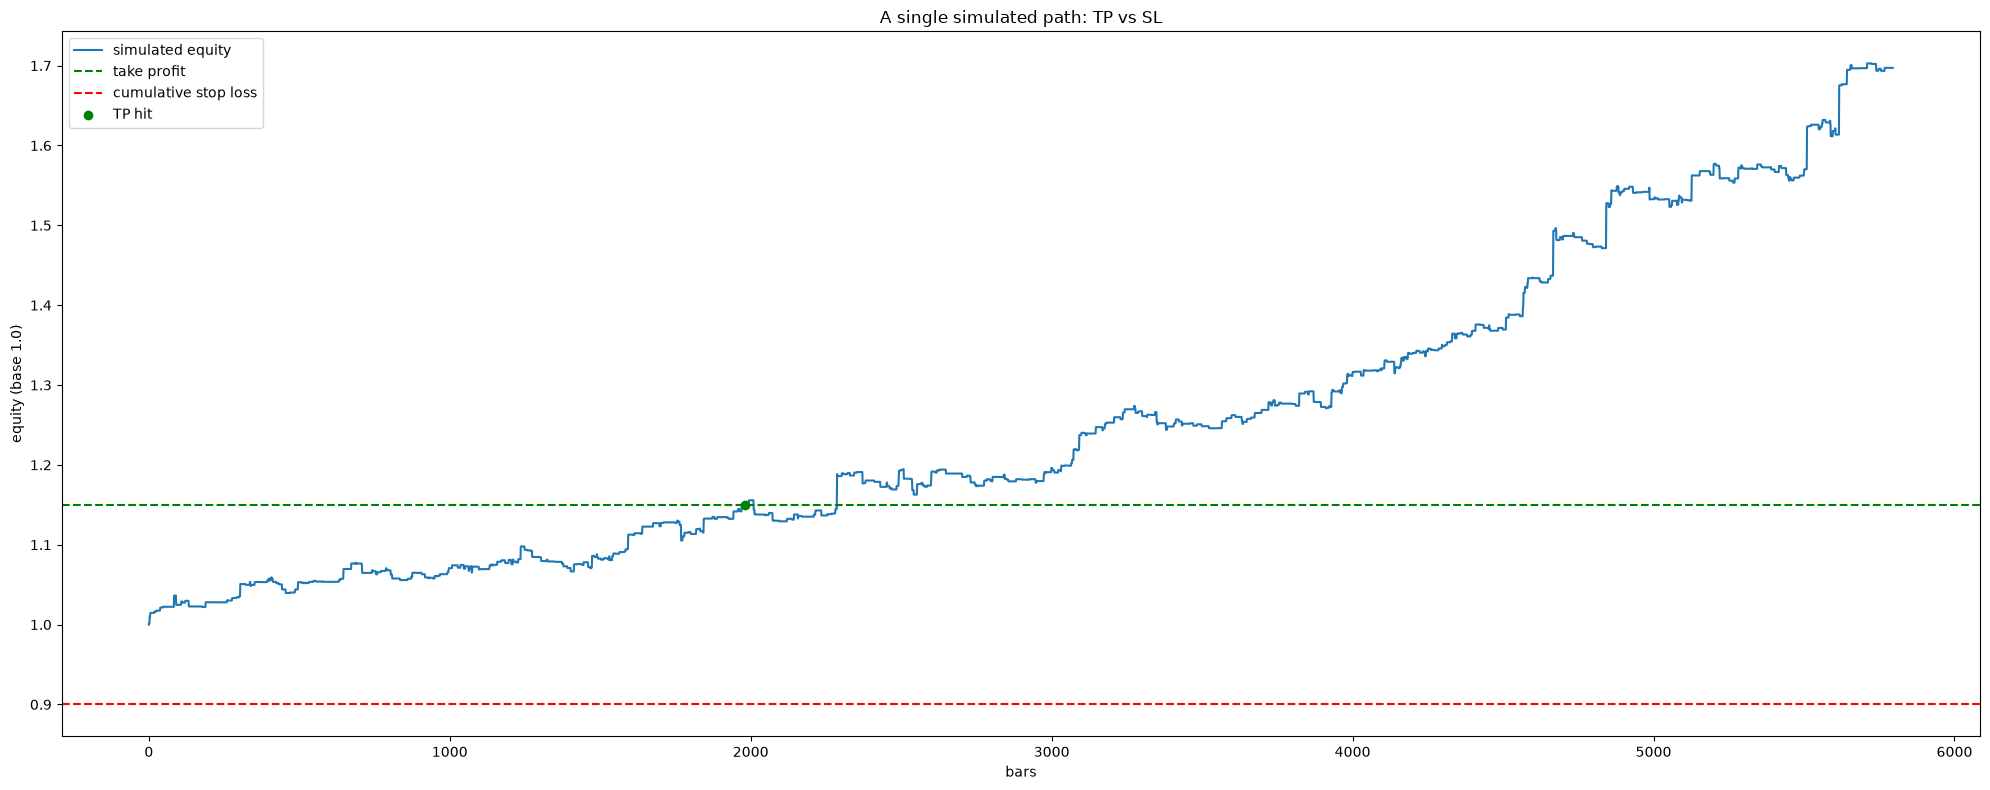

tp_idx: 1981  sl_idx: None


In [17]:
rng_single = np.random.default_rng()
r = sample_bootstrap_path(returns_simple, params, rng_single)
cum = (1 + r).cumprod()

tp_level = 1 + params["tp"]
sl_level = 1 - params["sl"]
hit_sl_cum = cum <= sl_level

n_days = params["n_bars"] // params["bars_per_day"]
daily_r = np.zeros(params["n_bars"])
for day in range(n_days):
    start = day * params["bars_per_day"]
    end = (day + 1) * params["bars_per_day"]
    daily_r[start:end] = np.cumprod(1 + r[start:end]) - 1
hit_sl_daily = daily_r <= -params["daily_sl"]

hit_sl = hit_sl_cum | hit_sl_daily
hit_tp = cum >= tp_level
tp_idx = np.argmax(hit_tp) if hit_tp.any() else None
sl_idx = np.argmax(hit_sl) if hit_sl.any() else None

fig, ax = plt.subplots(figsize=(20, 8))
ax.plot(cum, label="simulated equity")
ax.axhline(tp_level, color="green", linestyle="--", label="take profit")
ax.axhline(sl_level, color="red", linestyle="--", label="cumulative stop loss")
if tp_idx is not None:
    ax.scatter([tp_idx], [cum[tp_idx]], color="green", zorder=5, label="TP hit")
if sl_idx is not None:
    ax.scatter([sl_idx], [cum[sl_idx]], color="red", zorder=5, label="SL hit")
ax.set_title("A single simulated path: TP vs SL")
ax.set_xlabel("bars")
ax.set_ylabel("equity (base 1.0)")
ax.legend()
plt.tight_layout()
plt.show()

print("tp_idx:", tp_idx, " sl_idx:", sl_idx)

## 5. The full simulation function

We put all the pieces together into a function that, given the historical returns, the leverage and the challenge parameters, runs `n_sim` independent simulations and returns the aggregate metrics: probability of success, expected value, cost to pass, efficiency, probability of ruin.

Key points of the logic:
- returns are converted from log to simple **before** applying leverage (leverage scales the real P&L, not the log return)
- the daily loss limit test uses the return accumulated **since each day's open**, bar by bar — not just the closing bar
- once the challenge is passed, the "funded" account continues under its own rules (cumulative SL and daily SL recomputed from its own starting equity)
- the payout is estimated around the funded phase's equity peak, with a roughly one-month random offset (payouts are monthly, not instantaneous at the peak)

In [6]:
def run_simulation(log_returns, leverage, p, n_sim, seed=None):
    returns = np.exp(log_returns.dropna()) - 1  # log -> simple
    T = len(returns)

    block_size = min(T, max(1, p["block_size"]))
    n_blocks = int(np.ceil(p["n_bars"] / block_size))
    max_start_idx = T - block_size

    leveraged_returns = returns * leverage
    rng = np.random.default_rng(seed)

    result_list, bars_to_tp_list, bars_to_end_list = [], [], []
    final_return_list, loss_type_list = [], []
    max_drawdown_list, max_daily_drawdown_list = [], []

    for _ in range(n_sim):
        start_idx = rng.integers(0, max_start_idx + 1, size=n_blocks)
        r = np.concatenate(
            [leveraged_returns.values[s : s + block_size] for s in start_idx]
        )[: p["n_bars"]]

        cum = (1 + r).cumprod()
        tp_level = 1 + p["tp"]
        sl_level = 1 - p["sl"]

        if p["trailing_sl"]:
            drawdown = cum / np.maximum.accumulate(cum) - 1
            hit_sl_cum = drawdown <= -p["sl"]
        else:
            hit_sl_cum = cum <= sl_level

        n_days = p["n_bars"] // p["bars_per_day"]
        daily_r = np.zeros(p["n_bars"])
        for day in range(n_days):
            start = day * p["bars_per_day"]
            end = (day + 1) * p["bars_per_day"]
            daily_r[start:end] = np.cumprod(1 + r[start:end]) - 1
        hit_sl_daily = daily_r <= -p["daily_sl"]

        hit_sl = hit_sl_cum | hit_sl_daily
        hit_tp = cum >= tp_level

        tp_idx = np.argmax(hit_tp) if hit_tp.any() else None
        sl_idx = np.argmax(hit_sl) if hit_sl.any() else None

        sl_type = None
        if sl_idx is not None:
            if hit_sl_daily[sl_idx]:
                sl_type = "daily"
            elif hit_sl_cum[sl_idx]:
                sl_type = "cumulative"

        if tp_idx is not None and (sl_idx is None or tp_idx <= sl_idx):
            outcome = 1

            cum_after = cum[tp_idx:]
            daily_r_after = daily_r[tp_idx:]

            if p["trailing_sl"]:
                drawdown_after = cum_after / np.maximum.accumulate(cum_after) - 1
                hit_sl_cum_after = drawdown_after <= -p["sl"]
            else:
                hit_sl_cum_after = cum_after <= sl_level

            hit_sl_daily_after = daily_r_after <= -p["daily_sl"]
            hit_sl_after = hit_sl_cum_after | hit_sl_daily_after

            if hit_sl_after.any():
                sl_after_idx = np.argmax(hit_sl_after)
                end_idx = tp_idx + sl_after_idx
            else:
                end_idx = len(cum) - 1

            bars_to_tp = tp_idx
            bars_to_end = end_idx

            cum_funded = cum[tp_idx : end_idx + 1]
            max_idx = np.argmax(cum_funded) + tp_idx

            real_max_idx = (
                max_idx
                + rng.integers(0, p["bars_per_month"] + 1)
                - p["bars_per_month"] // 2
            )
            min_payout_idx = tp_idx + p["bars_per_month"]

            if min_payout_idx <= real_max_idx <= end_idx:
                final_return = cum[real_max_idx] - 1
            else:
                prev_real_max_idx = real_max_idx - p["bars_per_month"]
                if min_payout_idx <= prev_real_max_idx <= end_idx:
                    final_return = cum[prev_real_max_idx] - 1
                else:
                    final_return = 0

            daily_r_slice = daily_r[: end_idx + 1]
            cum_slice = cum[: end_idx + 1]

        elif sl_idx is not None:
            outcome = -1
            bars_to_tp = np.nan
            bars_to_end = sl_idx
            final_return = np.nan

            daily_r_slice = daily_r[: sl_idx + 1]
            cum_slice = cum[: sl_idx + 1]

        else:
            outcome = 0
            bars_to_tp = np.nan
            bars_to_end = len(cum) - 1
            final_return = np.nan

            daily_r_slice = daily_r
            cum_slice = cum

        drawdown_slice = cum_slice / np.maximum.accumulate(cum_slice) - 1
        max_drawdown_list.append(drawdown_slice.min())
        max_daily_drawdown_list.append(daily_r_slice.min())

        result_list.append(outcome)
        bars_to_tp_list.append(bars_to_tp)
        bars_to_end_list.append(bars_to_end)
        final_return_list.append(final_return)
        loss_type_list.append(sl_type)

    result_list = np.array(result_list)
    bars_to_tp_list = np.array(bars_to_tp_list, dtype=float)
    bars_to_end_list = np.array(bars_to_end_list, dtype=float)
    final_return_list = np.array(final_return_list, dtype=float)
    loss_type_list = np.array(loss_type_list)
    max_drawdown_list = np.array(max_drawdown_list, dtype=float)
    max_daily_drawdown_list = np.array(max_daily_drawdown_list, dtype=float)

    success_mask = result_list == 1
    loss_mask = result_list == -1

    loss_daily_rate = np.mean(loss_mask & (loss_type_list == "daily"))
    loss_cum_rate = np.mean(loss_mask & (loss_type_list == "cumulative"))

    success_rate = success_mask.mean()
    loss_rate = loss_mask.mean()
    no_event_rate = (result_list == 0).mean()

    avg_bars_to_tp = np.nanmean(bars_to_tp_list[success_mask]) if success_mask.any() else np.nan
    avg_bars_to_end = np.nanmean(bars_to_end_list)

    net_profit = np.maximum((final_return_list - p["tp"]) * p["capital"], 0)
    net_payout = net_profit * p["payout_pct"]

    monthly_cost = (bars_to_end_list / p["bars_per_month"]) * p["fixed_cost_month"]
    avg_monthly_cost = np.nanmean(monthly_cost)

    expected_payout = np.nanmean(net_payout[success_mask]) if success_mask.any() else 0

    # EV: the challenge fee is assumed refunded on passing -> weighted by (1-success_rate)
    # avg_monthly_cost is already an unconditional expectation, it should not be reweighted
    ev = success_rate * expected_payout - (1 - success_rate) * p["challenge_cost"] - avg_monthly_cost

    # cost_to_pass: expected gross outlay to get a funded account, refunded or not
    cost_to_pass = (p["challenge_cost"] + avg_monthly_cost) / success_rate if success_rate > 0 else 0
    efficiency = ev / cost_to_pass if cost_to_pass > 0 else 0
    prob_ruin = (1 - success_rate) ** (p["bankroll"] / (p["challenge_cost"] + avg_monthly_cost))

    return {
        "leverage": leverage,
        "success_rate": success_rate,
        "loss_rate": loss_rate,
        "no_event_rate": no_event_rate,
        "loss_daily_rate": loss_daily_rate,
        "loss_cumulative_rate": loss_cum_rate,
        "avg_max_drawdown": round(max_drawdown_list.mean(), 3),
        "avg_max_daily_drawdown": round(max_daily_drawdown_list.mean(), 3),
        "avg_days_to_tp": int(avg_bars_to_tp / p["bars_per_day"]) if success_mask.any() else np.nan,
        "avg_days_to_end": int(avg_bars_to_end / p["bars_per_day"]),
        "avg_final_return": round(np.nanmean(final_return_list), 3) if success_mask.any() else 0,
        "avg_net_payout": int(np.nanmean(net_payout)) if success_mask.any() else 0,
        "expected_value": round(ev, 1),
        "cost_to_pass": round(cost_to_pass, 1) if success_mask.any() else np.nan,
        "efficiency": round(efficiency, 3) if success_mask.any() else np.nan,
        "prob_ruin": round(prob_ruin, 4),
    }

## 6. Running the Monte Carlo for a single leverage

In [7]:
metrics = run_simulation(log_returns, leverage=1, p=params, n_sim=1000, seed=42)
pd.Series(metrics)

leverage                      1.000
success_rate                  0.845
loss_rate                     0.013
no_event_rate                 0.142
loss_daily_rate               0.000
loss_cumulative_rate          0.013
avg_max_drawdown             -0.066
avg_max_daily_drawdown       -0.021
avg_days_to_tp              128.000
avg_days_to_end             250.000
avg_final_return              0.272
avg_net_payout            11125.000
expected_value             9122.100
cost_to_pass                980.600
efficiency                    9.302
prob_ruin                     0.000
dtype: float64

## 7. The effect of leverage

We repeat the simulation for different leverage levels on the same historical data, to see how the probability of success and expected value move. More leverage means reaching the target faster, but also approaching the daily loss limit faster — the net effect isn't obvious and needs to be measured, not assumed.

In [8]:
rows = [run_simulation(log_returns, lev, params, n_sim=1000, seed=42) for lev in leverage_list]
results_df = pd.DataFrame(rows, index = leverage_list)
results_df.transpose()

,1,2,3,4,5,6,7,8,9,10
leverage,1.000,2.000,3.000,4.000,5.0000,6.0000,7.0000,8.0000,9.000,10.0000
success_rate,0.845,0.855,0.625,0.522,0.3960,0.3570,0.3410,0.3430,0.335,0.3660
loss_rate,0.013,0.136,0.375,0.478,0.6040,0.6430,0.6590,0.6570,0.665,0.6340
no_event_rate,0.142,0.009,0.000,0.000,0.0000,0.0000,0.0000,0.0000,0.000,0.0000
loss_daily_rate,0.000,0.039,0.249,0.394,0.5480,0.6150,0.6420,0.6450,0.654,0.6280
loss_cumulative_rate,0.013,0.097,0.126,0.084,0.0560,0.0280,0.0170,0.0120,0.011,0.0060
avg_max_drawdown,-0.066,-0.120,-0.120,-0.105,-0.0940,-0.0890,-0.0890,-0.0920,-0.095,-0.0980
avg_max_daily_drawdown,-0.021,-0.040,-0.053,-0.059,-0.0600,-0.0640,-0.0670,-0.0710,-0.075,-0.0790
avg_days_to_tp,128.000,67.000,32.000,19.000,11.0000,7.0000,6.0000,4.0000,4.000,3.0000
avg_days_to_end,250.000,218.000,96.000,38.000,17.0000,11.0000,7.0000,6.0000,5.000,5.0000


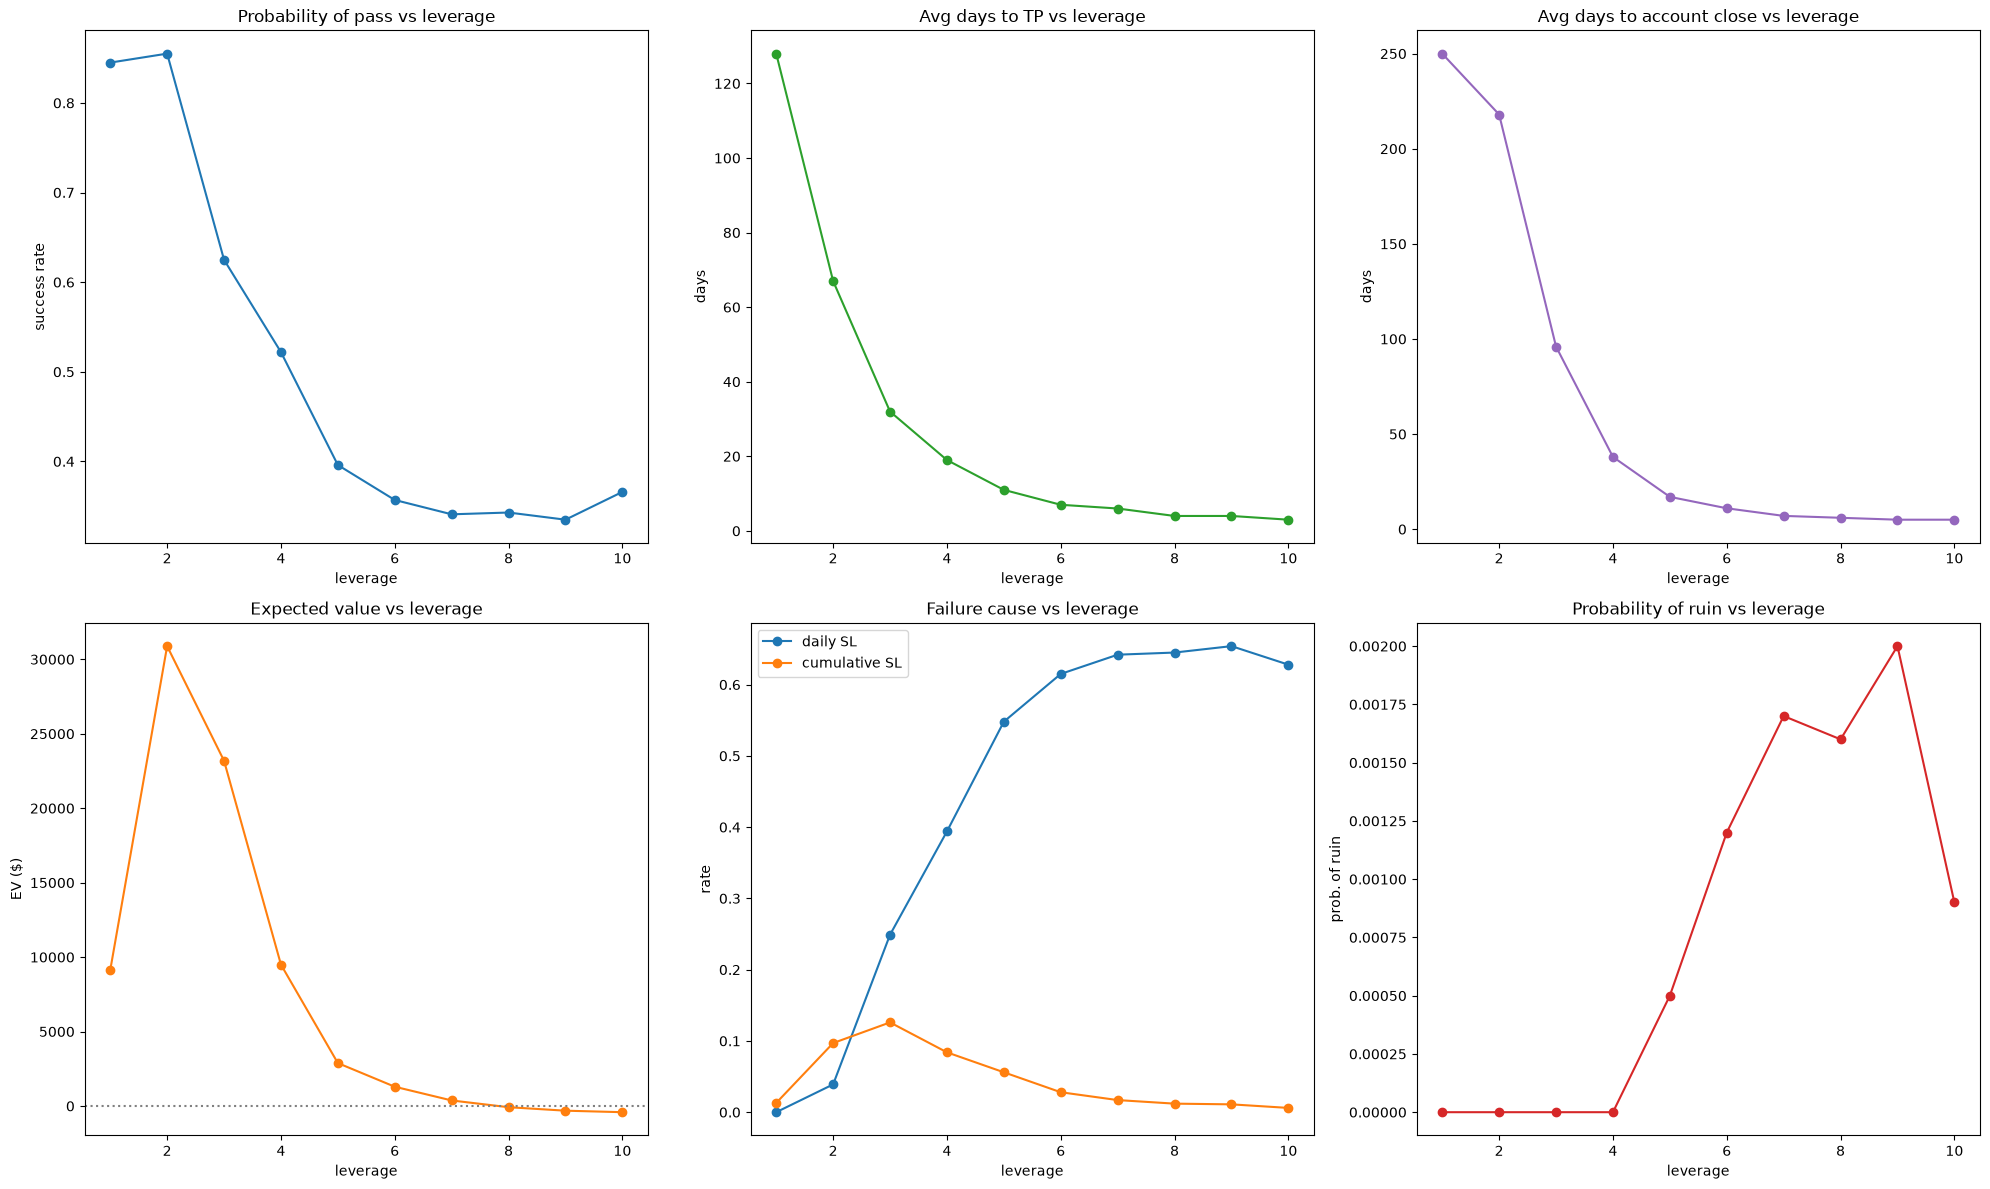

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

axes[0, 0].plot(results_df["leverage"], results_df["success_rate"], marker="o")
axes[0, 0].set_title("Probability of pass vs leverage")
axes[0, 0].set_xlabel("leverage")
axes[0, 0].set_ylabel("success rate")

axes[0, 1].plot(results_df["leverage"], results_df["avg_days_to_tp"], marker="o", color="tab:green")
axes[0, 1].set_title("Avg days to TP vs leverage")
axes[0, 1].set_xlabel("leverage")
axes[0, 1].set_ylabel("days")

axes[0, 2].plot(results_df["leverage"], results_df["avg_days_to_end"], marker="o", color="tab:purple")
axes[0, 2].set_title("Avg days to account close vs leverage")
axes[0, 2].set_xlabel("leverage")
axes[0, 2].set_ylabel("days")

axes[1, 0].plot(results_df["leverage"], results_df["expected_value"], marker="o", color="tab:orange")
axes[1, 0].axhline(0, color="grey", linestyle=":")
axes[1, 0].set_title("Expected value vs leverage")
axes[1, 0].set_xlabel("leverage")
axes[1, 0].set_ylabel("EV ($)")

axes[1, 1].plot(results_df["leverage"], results_df["loss_daily_rate"], marker="o", label="daily SL")
axes[1, 1].plot(results_df["leverage"], results_df["loss_cumulative_rate"], marker="o", label="cumulative SL")
axes[1, 1].set_title("Failure cause vs leverage")
axes[1, 1].set_xlabel("leverage")
axes[1, 1].set_ylabel("rate")
axes[1, 1].legend()

axes[1, 2].plot(results_df["leverage"], results_df["prob_ruin"], marker="o", color="tab:red")
axes[1, 2].set_title("Probability of ruin vs leverage")
axes[1, 2].set_xlabel("leverage")
axes[1, 2].set_ylabel("prob. of ruin")

plt.tight_layout()
plt.show()